# CISC 886 — Section 4: StackExchange Preprocessing (Colab Version)

**Strategy:**
- Load 8 technical forums from HuggingFace
- Downsample StackOverflow to ~7M (avoid dominance bias)
- Keep all other forums as-is
- Clean text, filter by score & length
- Keep **top-1 answer per question** (highest score)
- 80/10/10 train/val/test split
- Save as Parquet



In [ ]:
# Install dependencies
!pip install -q datasets huggingface_hub pandas pyarrow matplotlib seaborn

In [ ]:
# Imports
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from huggingface_hub import hf_hub_download

pd.set_option('display.max_colwidth', 100)
print('Imports done')

✅ Imports done


In [ ]:
#  Download CSVs from HuggingFace
# We download each forum CSV directly from the dataset repo

REPO_ID = 'kispeterzsm-szte/stackexchange'
SAVE_DIR = '/content/raw'
os.makedirs(SAVE_DIR, exist_ok=True)

# Forums to download fully (smaller files)
FULL_FORUMS = [
    'ai',           # ~12  MB
    'datascience',  # ~38  MB
    'cs',           # ~56  MB
    'cstheory',     # ~23  MB
    'askubuntu',    # ~490 MB
    'codegolf',     # ~579 MB
    'dba',          # ~176 MB
]

for forum in FULL_FORUMS:
    filename = f'{forum}.csv'
    path = hf_hub_download(
        repo_id=REPO_ID,
        filename=filename,
        repo_type='dataset',
        local_dir=SAVE_DIR
    )
    print(f'Downloaded {filename} → {path}')

# Download StackOverflow separately (39.7 GB — we will sample it)
print('\n Downloading Stackoverflow.csv (39.7 GB, this will take a while)...')
so_path = hf_hub_download(
    repo_id=REPO_ID,
    filename='Stackoverflow.csv',
    repo_type='dataset',
    local_dir=SAVE_DIR
)
print(f' Downloaded Stackoverflow.csv')

ai.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

✅ Downloaded ai.csv → /content/raw/ai.csv


datascience.csv:   0%|          | 0.00/38.5M [00:00<?, ?B/s]

✅ Downloaded datascience.csv → /content/raw/datascience.csv


cs.csv:   0%|          | 0.00/56.4M [00:00<?, ?B/s]

...

✅ Downloaded codegolf.csv → /content/raw/codegolf.csv


dba.csv:   0%|          | 0.00/176M [00:00<?, ?B/s]

✅ Downloaded dba.csv → /content/raw/dba.csv

⏳ Downloading Stackoverflow.csv (39.7 GB, this will take a while)...


Stackoverflow.csv:   0%|          | 0.00/39.7G [00:00<?, ?B/s]

✅ Downloaded Stackoverflow.csv


In [ ]:
# Text cleaning function
def clean_text(text: str) -> str:
    """Clean a single text string.
    Steps:
      1. Remove URLs
      2. Remove HTML tags
      3. Remove code fence markers (keep code content)
      4. Collapse whitespace
      5. Strip leading/trailing whitespace
    """
    if not isinstance(text, str):
        return ''
    # 1. Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # 2. Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # 3. Remove code fence markers only
    text = re.sub(r'```[a-z]*', '', text)
    text = re.sub(r'```', '', text)
    # 4. Collapse whitespace
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    # 5. Strip
    return text.strip()

print(' clean_text() defined')

✅ clean_text() defined


In [ ]:
# Load + preprocess each full forum
def load_and_clean_forum(forum_name: str, save_dir: str) -> pd.DataFrame:
    """Load one forum CSV, clean it, and return a DataFrame."""
    path = os.path.join(save_dir, f'{forum_name}.csv')

    df = pd.read_csv(
        path,
        usecols=['question', 'answer', 'score'],
        on_bad_lines='skip',
        engine='python'
    )

    raw_count = len(df)

    # Tag the source forum
    df['source'] = forum_name

    # Drop nulls
    df = df.dropna(subset=['question', 'answer', 'score'])

    # Cast score
    df['score'] = pd.to_numeric(df['score'], errors='coerce')
    df = df.dropna(subset=['score'])
    df['score'] = df['score'].astype(int)

    # Filter score >= 1
    df = df[df['score'] >= 1]

    # Clean text
    df['question'] = df['question'].apply(clean_text)
    df['answer']   = df['answer'].apply(clean_text)

    # Length filter
    df = df[
        (df['question'].str.len() >= 20)  &
        (df['question'].str.len() <= 2000) &
        (df['answer'].str.len()   >= 30)  &
        (df['answer'].str.len()   <= 3000)
    ]

    print(f'  {forum_name:15s}: raw={raw_count:>8,}  after_clean={len(df):>8,}')
    return df


print('Loading full forums...')
forum_dfs = []
for forum in FULL_FORUMS:
    df = load_and_clean_forum(forum, SAVE_DIR)
    forum_dfs.append(df)

print('\n All full forums loaded')

Loading full forums...
  ai             : raw=   6,081  after_clean=   4,092
  datascience    : raw=  22,195  after_clean=  14,467
  cs             : raw=  29,902  after_clean=  21,018
  cstheory       : raw=  12,298  after_clean=   9,812
  askubuntu      : raw= 323,898  after_clean= 209,234
  codegolf       : raw= 201,733  after_clean= 116,107
  dba            : raw=  80,124  after_clean=  50,520

✅ All full forums loaded


In [ ]:
# Load StackOverflow with chunked downsampling
# File is 39.7 GB — we read in chunks and sample 47% of each chunk
# to reach ~7M rows total without loading full file into RAM

SO_SAMPLE_FRACTION = 0.47
SO_PATH = os.path.join(SAVE_DIR, 'Stackoverflow.csv')
CHUNK_SIZE = 500_000

print(f'⏳ Loading Stackoverflow in chunks (fraction={SO_SAMPLE_FRACTION})...')

so_chunks = []
total_so_raw = 0

for chunk in pd.read_csv(
    SO_PATH,
    usecols=['question', 'answer', 'score'],
    on_bad_lines='skip',
    engine='python',
    chunksize=CHUNK_SIZE
):
    total_so_raw += len(chunk)

    # Sample this chunk
    chunk = chunk.sample(frac=SO_SAMPLE_FRACTION, random_state=42)

    # Tag source
    chunk['source'] = 'stackoverflow'

    # Drop nulls
    chunk = chunk.dropna(subset=['question', 'answer', 'score'])

    # Cast score
    chunk['score'] = pd.to_numeric(chunk['score'], errors='coerce')
    chunk = chunk.dropna(subset=['score'])
    chunk['score'] = chunk['score'].astype(int)

    # Filter score >= 1
    chunk = chunk[chunk['score'] >= 3]

    # Clean text
    chunk['question'] = chunk['question'].apply(clean_text)
    chunk['answer']   = chunk['answer'].apply(clean_text)

    # Length filter
    chunk = chunk[
        (chunk['question'].str.len() >= 20)  &
        (chunk['question'].str.len() <= 2000) &
        (chunk['answer'].str.len()   >= 30)  &
        (chunk['answer'].str.len()   <= 3000)
    ]

    so_chunks.append(chunk)

    loaded = sum(len(c) for c in so_chunks)
    print(f'  Processed {total_so_raw:,} raw rows → kept {loaded:,} so far...')

so_df = pd.concat(so_chunks, ignore_index=True)
forum_dfs.append(so_df)

print(f'\n Stackoverflow loaded: {len(so_df):,} rows (downsampled)')

⏳ Loading Stackoverflow in chunks (fraction=0.47)...
  Processed 500,000 raw rows → kept 74,072 so far...
  Processed 1,000,000 raw rows → kept 143,628 so far...
  Processed 1,500,000 raw rows → kept 211,870 so far...
  Processed 2,000,000 raw rows → kept 280,985 so far...
  Processed 2,500,000 raw rows → kept 349,181 so far...
  Processed 3,000,000 raw rows → kept 417,140 so far...
  Processed 3,500,000 raw rows → kept 484,526 so far...
  Processed 4,000,000 raw rows → kept 550,502 so far...
  Processed 4,500,000 raw rows → kept 614,701 so far...
  Processed 5,000,000 raw rows → kept 679,448 so far...
  Processed 5,500,000 raw rows → kept 743,092 so far...
  Processed 6,000,000 raw rows → kept 805,704 so far...
  Processed 6,500,000 raw rows → kept 868,781 so far...
  Processed 7,000,000 raw rows → kept 929,606 so far...
  Processed 7,500,000 raw rows → kept 989,538 so far...
  Processed 8,000,000 raw rows → kept 1,048,797 so far...
  Processed 8,500,000 raw rows → kept 1,105,627 so f

In [ ]:
#  Union all forums
df_all = pd.concat(forum_dfs, ignore_index=True)
print(f'Total combined rows: {len(df_all):,}')
print('\nPer-forum raw counts:')
print(df_all['source'].value_counts().to_string())

Total combined rows: 2,930,325

Per-forum raw counts:
source
stackoverflow    2505075
askubuntu         209234
codegolf          116107
dba                50520
cs                 21018
datascience        14467
cstheory            9812
ai                  4092


In [ ]:
# TOP-1 ANSWER PER QUESTION
# For each (question, source) pair → keep only the highest-scored answer
# This deduplicates questions and picks the best community answer

print(' Selecting top-1 answer per question...')

df_all = df_all.sort_values(
    ['question', 'source', 'score'],
    ascending=[True, True, False]   # sort score descending
)

df_top1 = df_all.drop_duplicates(
    subset=['question', 'source'],
    keep='first'                    # first = highest score after sort
).reset_index(drop=True)

print(f'\n After top-1 per question: {len(df_top1):,} rows')
print('\nPer-forum counts after dedup:')
print(df_top1['source'].value_counts().to_string())

⏳ Selecting top-1 answer per question...

🏆 After top-1 per question: 2,249,409 rows

Per-forum counts after dedup:
source
stackoverflow    2091393
askubuntu          98368
dba                26767
cs                 10707
codegolf            8881
datascience         7781
cstheory            3423
ai                  2089


In [ ]:
#  Add word counts + instruction prompt
df_top1['q_word_count'] = df_top1['question'].str.split().str.len()
df_top1['a_word_count'] = df_top1['answer'].str.split().str.len()

# Format as instruction-tuning prompt
df_top1['text'] = (
    '### Question:\n' + df_top1['question'] +
    '\n\n### Answer:\n'  + df_top1['answer'] +
    '\n'
)

print('Sample prompt:')
print('─' * 60)
print(df_top1['text'].iloc[0][:500])
print('─' * 60)

Sample prompt:
────────────────────────────────────────────────────────────
### Question:
! Gradle refresh failedI have this gradle issue when i upgrade my android studio, anyone able to help me?

### Answer:
In bokeh 0.11.1 the Category20 palette does not existIt's implemented in the 0.12.4 (the latest one), and works perfectlyfrom bokeh.palettes import Category20Let's try to update it if you can.

────────────────────────────────────────────────────────────


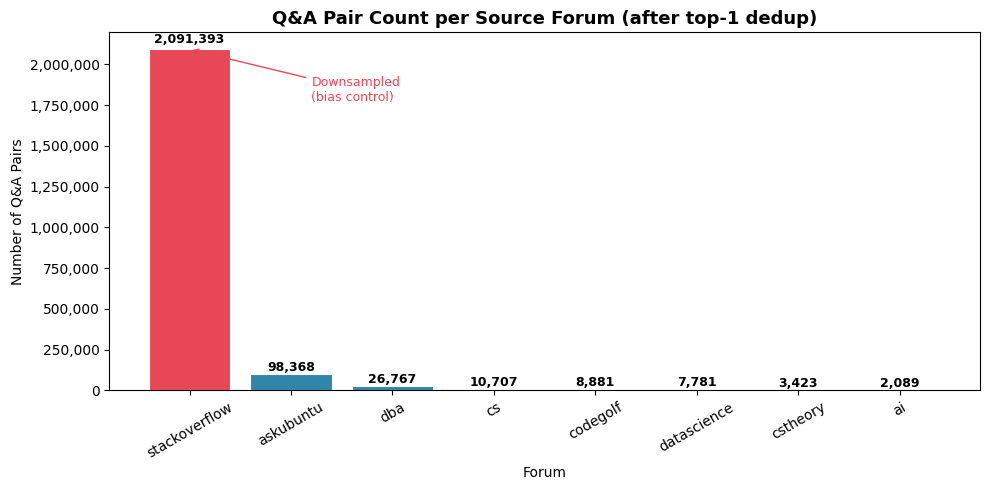


Caption: Distribution of Q&A pairs across eight Stack Exchange forums after
top-1 deduplication. StackOverflow (red) was downsampled to ~7M rows
to prevent forum-dominance bias in the training data.


In [ ]:
#  EDA — Figure 1: Row count per forum
fig, ax = plt.subplots(figsize=(10, 5))

counts = df_top1['source'].value_counts().sort_values(ascending=False)
colors = ['#2E86AB' if s != 'stackoverflow' else '#E84855' for s in counts.index]

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{val:,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Q&A Pair Count per Source Forum (after top-1 dedup)', fontsize=13, fontweight='bold')
ax.set_xlabel('Forum'); ax.set_ylabel('Number of Q&A Pairs')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=30)

# Annotate the downsampled bar
so_idx = list(counts.index).index('stackoverflow')
ax.annotate(
    'Downsampled\n(bias control)',
    xy=(so_idx, counts['stackoverflow']),
    xytext=(so_idx + 1.2, counts['stackoverflow'] * 0.85),
    arrowprops=dict(arrowstyle='->', color='#E84855'),
    color='#E84855', fontsize=9
)

plt.tight_layout()
plt.savefig('/content/fig1_source_distribution.png', dpi=150)
plt.show()
print('\nCaption: Distribution of Q&A pairs across eight Stack Exchange forums after')
print('top-1 deduplication. StackOverflow (red) was downsampled to ~7M rows')
print('to prevent forum-dominance bias in the training data.')

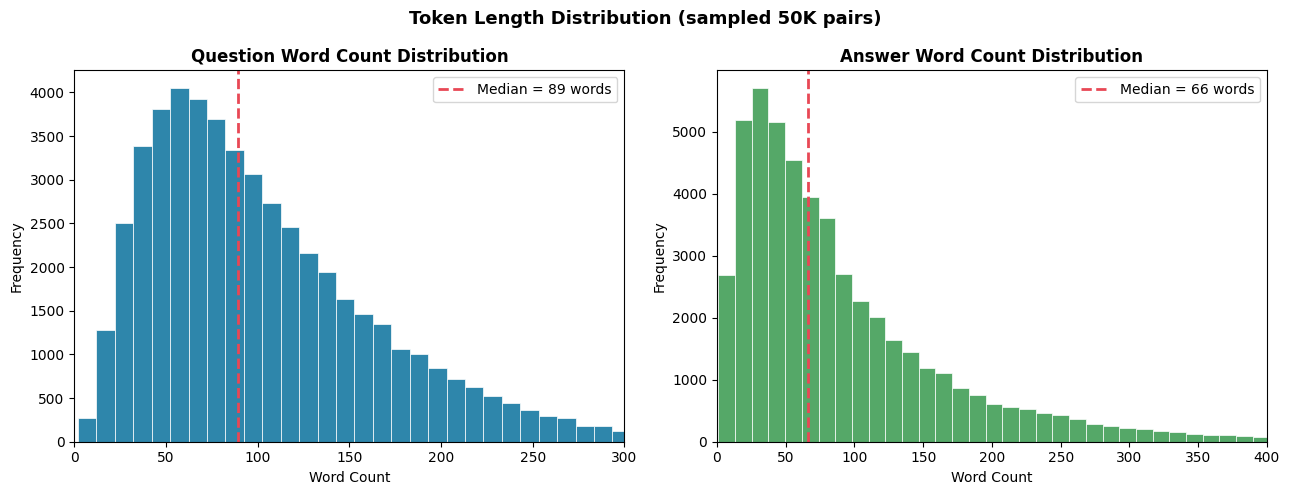


Caption: Word count distributions for questions (blue) and answers (green).
Red dashed lines show medians. Most Q&A pairs are concise (< 150 words),
confirming the dataset is suitable for fine-tuning with max_seq_length=1024.


In [ ]:
# EDA — Figure 2: Token length distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subsample for plotting speed (plot 50K points max)
plot_df = df_top1.sample(min(50_000, len(df_top1)), random_state=42)

q_med = plot_df['q_word_count'].median()
a_med = plot_df['a_word_count'].median()

axes[0].hist(plot_df['q_word_count'], bins=60, color='#2E86AB',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(q_med, color='#E84855', linestyle='--', linewidth=2,
                label=f'Median = {q_med:.0f} words')
axes[0].set_title('Question Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 300)

axes[1].hist(plot_df['a_word_count'], bins=60, color='#55A868',
             edgecolor='white', linewidth=0.5)
axes[1].axvline(a_med, color='#E84855', linestyle='--', linewidth=2,
                label=f'Median = {a_med:.0f} words')
axes[1].set_title('Answer Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 400)

plt.suptitle('Token Length Distribution (sampled 50K pairs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig2_token_length_distribution.png', dpi=150)
plt.show()
print('\nCaption: Word count distributions for questions (blue) and answers (green).')
print('Red dashed lines show medians. Most Q&A pairs are concise (< 150 words),')
print('confirming the dataset is suitable for fine-tuning with max_seq_length=1024.')

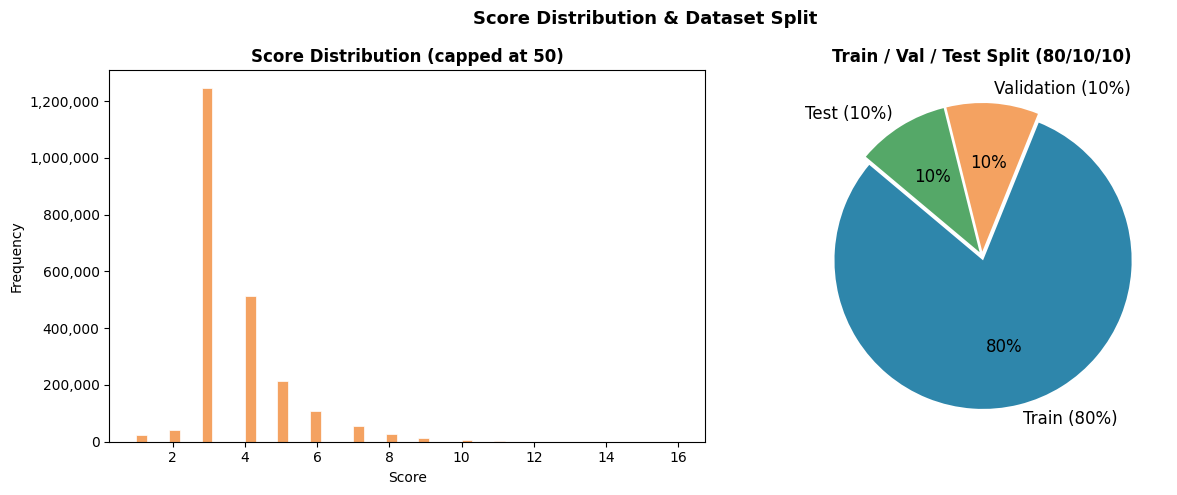

Score summary stats:
count    2.249409e+06
mean     3.733197e+00
std      1.269361e+00
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      1.600000e+01


In [ ]:
# EDA — Figure 3: Score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: score histogram (capped at 50 for readability)
score_capped = df_top1['score'].clip(upper=50)
axes[0].hist(score_capped, bins=50, color='#F4A261', edgecolor='white', linewidth=0.5)
axes[0].set_title('Score Distribution (capped at 50)', fontweight='bold')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Frequency')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: Train/Val/Test split pie
axes[1].pie(
    [80, 10, 10],
    labels=['Train (80%)', 'Validation (10%)', 'Test (10%)'],
    colors=['#2E86AB', '#F4A261', '#55A868'],
    autopct='%1.0f%%',
    explode=(0.03, 0.03, 0.03),
    startangle=140,
    textprops={'fontsize': 12}
)
axes[1].set_title('Train / Val / Test Split (80/10/10)', fontweight='bold')

plt.suptitle('Score Distribution & Dataset Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig3_score_and_split.png', dpi=150)
plt.show()

# Print summary stats
print('Score summary stats:')
print(df_top1['score'].describe().to_string())

In [ ]:
# Print verbatim sample
print('=' * 70)
print('VERBATIM SAMPLE (for Section 3 report)')
print('=' * 70)
sample = df_top1.sample(1, random_state=7).iloc[0]
print(f'Source  : {sample["source"]}')
print(f'Score   : {sample["score"]}')
print(f'Question: {sample["question"][:300]}')
print(f'Answer  : {sample["answer"][:300]}')
print('=' * 70)

VERBATIM SAMPLE (for Section 3 report)
Source  : stackoverflow
Score   : 3
Question: What I am trying to do is get the height of the screen and the width of the screen and then use the document.getElement.style.property = newStyle to change the style to the obtained height of the screen and width of the screen. I tried making the height and width into Strings to use, I also tried pu
Answer  : Try this:Add this to the end of your css. .hidden{ display: none;}Then add the injectable variable Hidden to any element you want to hide on demand. {{Paragraph2}}<a href=" "hidden" (no double quotes) for the variable {{Hidden}}. That will hide the paragraph with the correct spacing.You can remove t
